# Fairness Evaluation Example

This notebook shows how to evaluate an unsupervised embedding on the Adult dataset.

We use the Adult dataset with `sex` as the sensitive attribute and a PCA embedding, then compute:
- Percentage of variance retained
- MMD between sensitive groups
- Adversarial leakage for predicting the sensitive attribute

In [11]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

ROOT = Path.cwd().resolve()
if (ROOT / "src").exists():
    sys.path.insert(0, str(ROOT / "src"))
elif (ROOT.parent / "src").exists():
    sys.path.insert(0, str(ROOT.parent / "src"))

from fair_repr_eval import UnsupervisedFairnessEvaluator

sns.set_theme(style="whitegrid")

## 1) Load Adult Dataset

In [14]:
try:
    data = fetch_openml(name="adult", version=2, as_frame=True)
except Exception:
    data = fetch_openml(name="adult", version=1, as_frame=True)

X_raw = data.data.copy().reset_index(drop=True)
X_raw["sex"] = X_raw["sex"].astype(str).str.strip()

sample_size = min(3000, len(X_raw))
X_raw = X_raw.sample(n=sample_size, random_state=42).reset_index(drop=True)
sensitive = X_raw["sex"].astype(str).values
feature_cols = [c for c in X_raw.columns if c != "sex"]
X_features = X_raw[feature_cols].copy()

numeric_features = X_features.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_features.columns if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ]
)
X = preprocessor.fit_transform(X_features)

print("X shape:", X.shape)
print("Sensitive groups:", pd.Series(sensitive).value_counts(normalize=True).to_dict())
print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Encoded feature matrix shape:", X.shape)

/opt/homebrew/anaconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


X shape: (3000, 103)
Sensitive groups: {'Male': 0.67, 'Female': 0.33}
Numeric features: 6
Categorical features: 7
Encoded feature matrix shape: (3000, 103)


## 2) Fit a PCA Embedding and Evaluate Fairness

In [15]:
model = UnsupervisedFairnessEvaluator(
    PCA(n_components=2, random_state=0),
    variance_cv=5,
    adversarial_cv=5,
    random_state=0,
)
model.fit(X, sensitive=sensitive)

model.metrics_

{'variance_retained_percent': 4.91446039096155,
 'mmd_mean': 0.055556419944610136,
 'mmd_max': 0.055556419944610136,
 'mmd_min': 0.055556419944610136,
 'mmd_gamma': 0.14008894906639016,
 'mmd_pairwise': {'Female__vs__Male': 0.055556419944610136},
 'adversarial_accuracy_mean': 0.6636666666666666,
 'adversarial_accuracy_std': 0.011803954139750522,
 'adversarial_balanced_accuracy_mean': 0.542431780491482,
 'adversarial_balanced_accuracy_std': 0.011592297537481738,
 'adversarial_majority_class_baseline': 0.67}

## 3) Visualize the Embedding

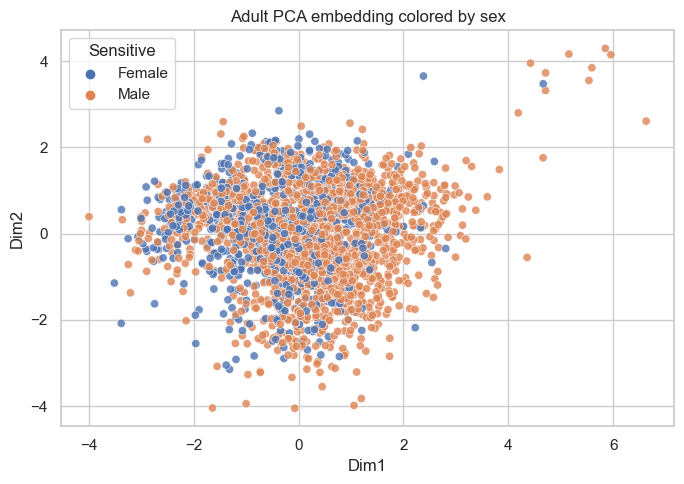

In [16]:
embedding = model.embedding_
plot_df = {
    "Dim1": embedding[:, 0],
    "Dim2": embedding[:, 1],
    "Sensitive": sensitive.astype(str),
}

plt.figure(figsize=(7, 5))
sns.scatterplot(data=plot_df, x="Dim1", y="Dim2", hue="Sensitive", alpha=0.8)
plt.title("Adult PCA embedding colored by sex")
plt.tight_layout()
plt.show()

## 4) Interpret the Metrics

- Higher variance retained means the embedding preserves more of the original structure.
- Lower MMD means the sex groups are closer in the learned space.
- Lower adversarial balanced accuracy means sex is harder to recover from the embedding.